In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing import sequence

In [2]:
# Keep only top 10,000 most frequent words
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
# Pad sequences to same length
max_len = 200

X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

In [4]:
model = Sequential()

# Embedding Layer
model.add(Embedding(vocab_size, 128, input_length=max_len))

# LSTM Layer
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Output Layer (Binary classification)
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train, y_train,
                    epochs=3,
                    batch_size=64,
                    validation_data=(X_test, y_test))

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 311s 784ms/step - accuracy: 0.7645 - loss: 0.4865 - val_accuracy: 0.8593 - val_loss: 0.3381
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 284s 686ms/step - accuracy: 0.8524 - loss: 0.3519 - val_accuracy: 0.8439 - val_loss: 0.3658
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 362s 788ms/step - accuracy: 0.8869 - loss: 0.2834 - val_accuracy: 0.8513 - val_loss: 0.3472


In [6]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.8513 - loss: 0.3472
Test Accuracy: 0.8513200283050537


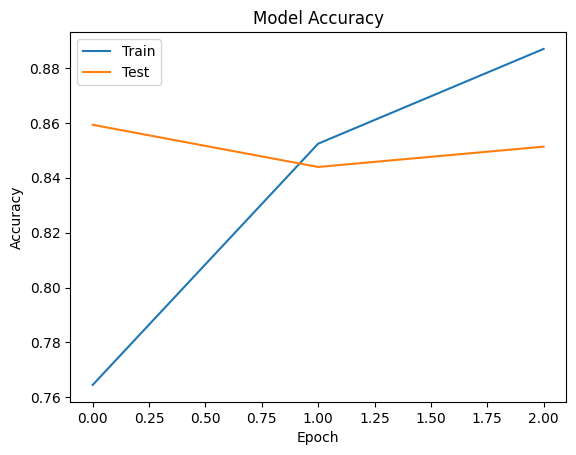

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Test'])
plt.show()

In [8]:
# Predict first 5 reviews
predictions = model.predict(X_test[:5])

for i, pred in enumerate(predictions):
    print("Review", i+1, "Sentiment:", "Positive" if pred > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
Review 1 Sentiment: Negative
Review 2 Sentiment: Positive
Review 3 Sentiment: Positive
Review 4 Sentiment: Negative
Review 5 Sentiment: Positive
